# Predictive Analytics for Diabetes Risk Classification

**Andrew Chongaway**

Can routinely collected health indicators classify diabetes status accurately enough to support proactive screening? This notebook builds and compares three classification models on the public BRFSS-derived **Diabetes Health Indicators** dataset (250,000+ observations, 21 predictors), evaluating each with metrics appropriate for an imbalanced target.

**Data:** [Diabetes Health Indicators Dataset (Kaggle)](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) — public, derived from the CDC Behavioral Risk Factor Surveillance System (BRFSS). Download `diabetesclassification.csv` per `data/README.md` before running.

**Models:** Logistic regression (interpretable baseline), decision tree (tuned), random forest (tuned) — all with class weighting to address target imbalance, and hyperparameters selected by cross-validated grid search optimizing F1.

## Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)

RANDOM_STATE = 42

## Data Loading and Quality Checks

Load the dataset and confirm structure, missingness, duplication, and the distribution of the original three-level target (`Diabetes_012`: 0 = no diabetes, 1 = pre-diabetes, 2 = diabetes).

In [2]:
df = pd.read_csv("diabetesclassification.csv")

In [3]:
print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

In [4]:
print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution (Diabetes_012):")
print(df["Diabetes_012"].value_counts())
print("\nTarget proportions:")
print(df["Diabetes_012"].value_counts(normalize=True))



Missing values (top 10):
Diabetes_012    0
HighBP          0
Education       0
Age             0
Sex             0
DiffWalk        0
PhysHlth        0
MentHlth        0
GenHlth         0
NoDocbcCost     0
dtype: int64

Duplicate rows: 23899

Target distribution (Diabetes_012):
Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64

Target proportions:
Diabetes_012
0    0.842412
2    0.139333
1    0.018255
Name: proportion, dtype: float64


No missing values were present, so no imputation was required, and all fields were already numeric. The class distribution confirms substantial imbalance — the modeling choices below (class weights, F1-optimized tuning, PR-AUC reporting) follow from that.

## Target Definition

The three-level target is converted to binary — **confirmed diabetes (1) vs. not (0)** — focusing the model on the population of clearest clinical and financial consequence. Pre-diabetes is grouped with the negative class, a limitation discussed in the conclusions.

In [5]:
df["Diabetes_binary"] = (df["Diabetes_012"] == 2).astype(int)

X = df.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df["Diabetes_binary"]

print("X shape:", X.shape)
print("Diabetes prevalence:", y.mean())

X shape: (253680, 21)
Diabetes prevalence: 0.13933301797540207


## Train/Test Split and Baseline

A stratified 80/20 split preserves class proportions. The majority-class baseline accuracy is computed first: with an imbalanced target, any model must be judged against the accuracy achievable by always predicting "no diabetes," which is why accuracy alone is not the headline metric here.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())
print(f"Majority-class baseline accuracy: {baseline_acc:.4f}")

Train prevalence: 0.13933400346893723
Test prevalence: 0.13932907600126143
Majority-class baseline accuracy: 0.8607


## Evaluation Helpers

A single evaluation function keeps model comparison consistent: classification report, confusion matrix, ROC-AUC, and PR-AUC (the more informative curve under class imbalance).

In [7]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(values_format="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    if y_score is not None:
        roc = roc_auc_score(y_test, y_score)
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        pr_auc = auc(recall, precision)
        print(f"{name} ROC-AUC: {roc:.4f}")
        print(f"{name} PR-AUC : {pr_auc:.4f}")

    return y_pred

def metric_row(name, y_true, y_pred, y_score=None):
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        row["ROC_AUC"] = roc_auc_score(y_true, y_score)
    else:
        row["ROC_AUC"] = np.nan
    return row

## Model 1 — Logistic Regression

Interpretable baseline. Features are standardized in a pipeline; class weights offset the imbalance; regularization strength `C` is selected by 3-fold stratified cross-validation optimizing F1.

Best LR params: {'lr__C': 1}
Best CV F1: 0.44303568607676186

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9495    0.7267    0.8233     43667
           1     0.3107    0.7611    0.4413      7069

    accuracy                         0.7315     50736
   macro avg     0.6301    0.7439    0.6323     50736
weighted avg     0.8605    0.7315    0.7701     50736



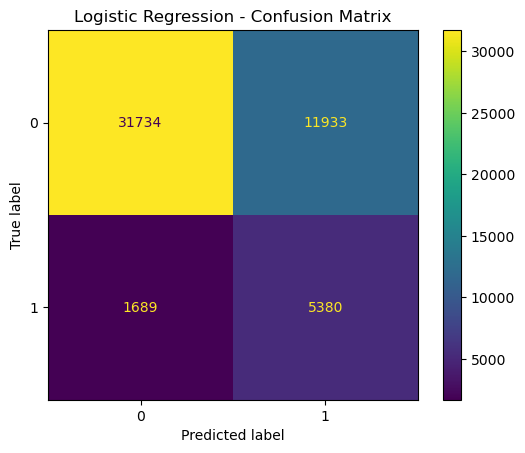

Logistic Regression ROC-AUC: 0.8196
Logistic Regression PR-AUC : 0.3924


In [8]:

lr_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

lr_grid = {
    "lr__C": [0.01, 0.1, 1, 5, 10]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

lr_search = GridSearchCV(
    lr_pipe,
    lr_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print("Best LR params:", lr_search.best_params_)
print("Best CV F1:", lr_search.best_score_)

best_lr = lr_search.best_estimator_
y_pred_lr = evaluate_model(best_lr, X_test, y_test, "Logistic Regression")

# scores for ROC_AUC in the comparison table
y_score_lr = best_lr.predict_proba(X_test)[:, 1]

# Used due to interpretability and typical performance in classification
# Standardscaler use to reduce variable influence with class weights as balance to account for imbalance in class distribution

## Model 2 — Decision Tree (Tuned)

Captures non-linear relationships. Depth and leaf-size constraints are grid-searched to control the overfitting a fully grown tree exhibits on this data.

Best DT params: {'max_depth': 8, 'min_samples_leaf': 100, 'min_samples_split': 2}
Best CV F1: 0.43168761832530617

===== Decision Tree (Tuned) =====
              precision    recall  f1-score   support

           0     0.9517    0.6945    0.8030     43667
           1     0.2930    0.7821    0.4263      7069

    accuracy                         0.7067     50736
   macro avg     0.6223    0.7383    0.6147     50736
weighted avg     0.8599    0.7067    0.7505     50736



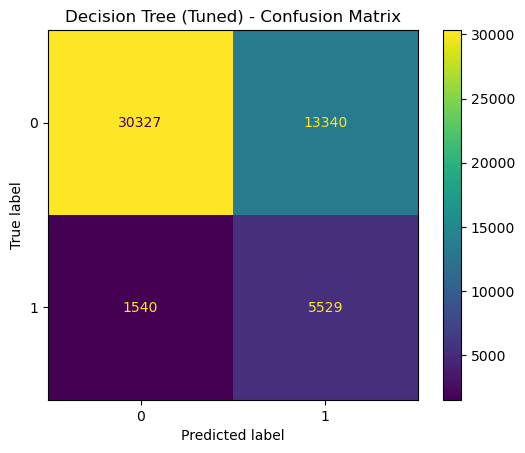

Decision Tree (Tuned) ROC-AUC: 0.8135
Decision Tree (Tuned) PR-AUC : 0.4159


In [9]:
dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

dt_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 50, 200],
    "min_samples_leaf": [1, 25, 100]
}

dt_search = GridSearchCV(
    dt,
    dt_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

print("Best DT params:", dt_search.best_params_)
print("Best CV F1:", dt_search.best_score_)

best_dt = dt_search.best_estimator_
y_pred_dt = evaluate_model(best_dt, X_test, y_test, "Decision Tree (Tuned)")

# Decision trees have predict_proba
y_score_dt = best_dt.predict_proba(X_test)[:, 1]

# Beneficial in non-linear relationships in interactions between predictors and target values

## Model 3 — Random Forest (Tuned)

Ensemble comparison: bootstrapped trees with randomized feature selection reduce variance and decorrelate errors. `class_weight="balanced_subsample"` re-weights within each bootstrap sample.

Best RF params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 50, 'n_estimators': 400}
Best CV F1: 0.45866797444868007

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9394    0.7885    0.8573     43667
           1     0.3442    0.6855    0.4583      7069

    accuracy                         0.7742     50736
   macro avg     0.6418    0.7370    0.6578     50736
weighted avg     0.8564    0.7742    0.8017     50736



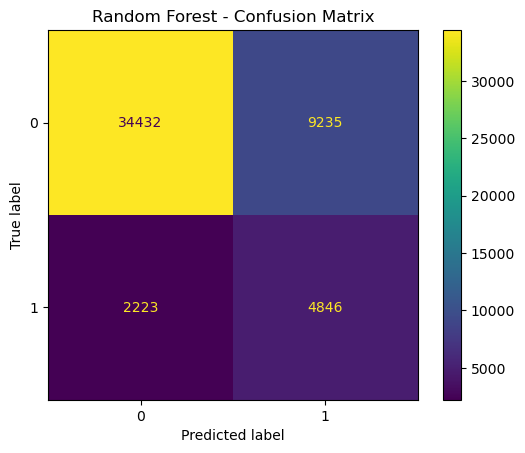

Random Forest ROC-AUC: 0.8200
Random Forest PR-AUC : 0.4161


GenHlth                 0.215550
HighBP                  0.189515
BMI                     0.140588
Age                     0.102174
HighChol                0.059344
Income                  0.045513
PhysHlth                0.041487
MentHlth                0.035609
Education               0.028807
DiffWalk                0.026771
HeartDiseaseorAttack    0.015156
Sex                     0.014884
Smoker                  0.012013
Fruits                  0.011723
HvyAlcoholConsump       0.011423
dtype: float64

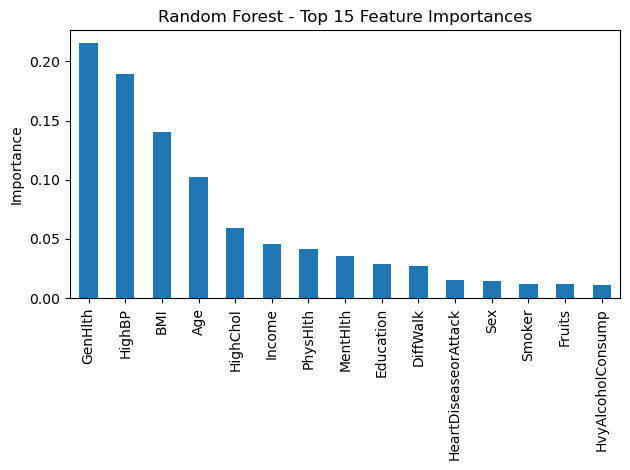

In [10]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 16],
    "min_samples_split": [2, 50],
    "min_samples_leaf": [1, 25],
    "max_features": ["sqrt", 0.5]
}

rf_search = GridSearchCV(
    rf,
    rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best CV F1:", rf_search.best_score_)

best_rf = rf_search.best_estimator_
y_pred_rf = evaluate_model(best_rf, X_test, y_test, "Random Forest")

y_score_rf = best_rf.predict_proba(X_test)[:, 1]


importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances.head(15))

importances.head(15).plot(kind="bar")
plt.title("Random Forest - Top 15 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Reduces variance and reduces overfitting with feature importance used to identify influential predictors 

## Model Comparison

In [11]:
results = []
results.append(metric_row("Logistic Regression", y_test, y_pred_lr, y_score_lr))
results.append(metric_row("Decision Tree (Tuned)", y_test, y_pred_dt, y_score_dt))
results.append(metric_row("Random Forest", y_test, y_pred_rf, y_score_rf))

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
display(results_df)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.774164,0.344152,0.685528,0.458251,0.820039
0,Logistic Regression,0.731512,0.310749,0.761069,0.441309,0.819631
1,Decision Tree (Tuned),0.706717,0.293020,0.782147,0.426324,0.813500


## Conclusions

**Random forest performed best across all metrics except recall**, where the decision tree's aggressive positive predictions traded precision for sensitivity. Logistic regression remained competitive on ROC-AUC while offering the interpretability advantage; the untuned decision tree demonstrated clear overfitting before constraint tuning.

**Recommendation.** For a screening-oriented use case — flagging elevated-risk individuals for follow-up testing and preventive education, where a false positive costs little relative to a missed case — the random forest is the recommended model.

**Limitations.**
- Survey-based, self-reported data introduces measurement and response-pattern bias.
- Internal validation only; external population performance is untested.
- The binary target does not distinguish pre-diabetes, the stage where preventive intervention has the greatest leverage.

**Next steps.** Extend the framework to additional chronic conditions to assess utility across a health system, and evaluate threshold tuning against the recall requirements of a real screening workflow.